In [66]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from utils import train, coords_2_strain_nn, nn_fpass
from utils import train_colloc_parallel as train_colloc, init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_iso, init_params_iso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity, merge_c_s_params_iso, split_c_s_params_iso
from fem import plotmesh, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))


with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/stiff2_hetero.npy', 'rb') as f:
    _,_,_,_,P_xx_gt,P_yy_gt = pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/stiff2_hetero_disp.npy', 'rb') as f:
    x,y,ux_hist,uy_hist = pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/temp.npy', 'rb') as f:
    E_hist_dic = pickle.load(f)

x1 = 4
x2 = 42
y1 = 2
y2 = 40
out = []
for aux in E_hist_dic:
    out.append(aux.transpose([2,0,1]).reshape([42,43,2,2]).transpose([1,0,2,3])[x1:x2,y1:y2,:,:].reshape([-1,2,2])) # I know. wtf?
E_hist_dic = np.array(out)
elem_X = np.stack([x.flatten(),y.flatten()]).T


# we don't need to use all of that data
i1 = 10
i2 = None
skip = 30
P_xx_gt = jnp.array(P_xx_gt[i1:i2:skip])
P_yy_gt = jnp.array(P_yy_gt[i1:i2:skip])
ux_hist = jnp.array(ux_hist[i1:i2:skip])
uy_hist = jnp.array(uy_hist[i1:i2:skip])

E_hist_dic = E_hist_dic[i1:i2:skip]




def coords_2_disp_x(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    t = t.astype(int)
    return out[0,0]*disps_x_stdv[t] + disps_x_mean[t]
def coords_2_disp_y(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    t = t.astype(int)
    return out[0,1]*disps_y_stdv[t] + disps_y_mean[t]

def F_xx_fn(inp,params):
    return grad(coords_2_disp_x           )(inp[0], inp[1], inp[2], params) + 1.0
def F_yy_fn(inp,params):
    return grad(coords_2_disp_y, argnums=1)(inp[0], inp[1], inp[2], params) + 1.0
def F_yx_fn(inp,params):
    return grad(coords_2_disp_y           )(inp[0], inp[1], inp[2], params)
def F_xy_fn(inp,params):
    return grad(coords_2_disp_x, argnums=1)(inp[0], inp[1], inp[2], params)

coords_2_strain_nn2 = vmap(lambda inp, params: jnp.stack([F_xx_fn(inp, params), F_xy_fn(inp, params), F_yx_fn(inp, params), F_yy_fn(inp,params)]), in_axes=(0, None))


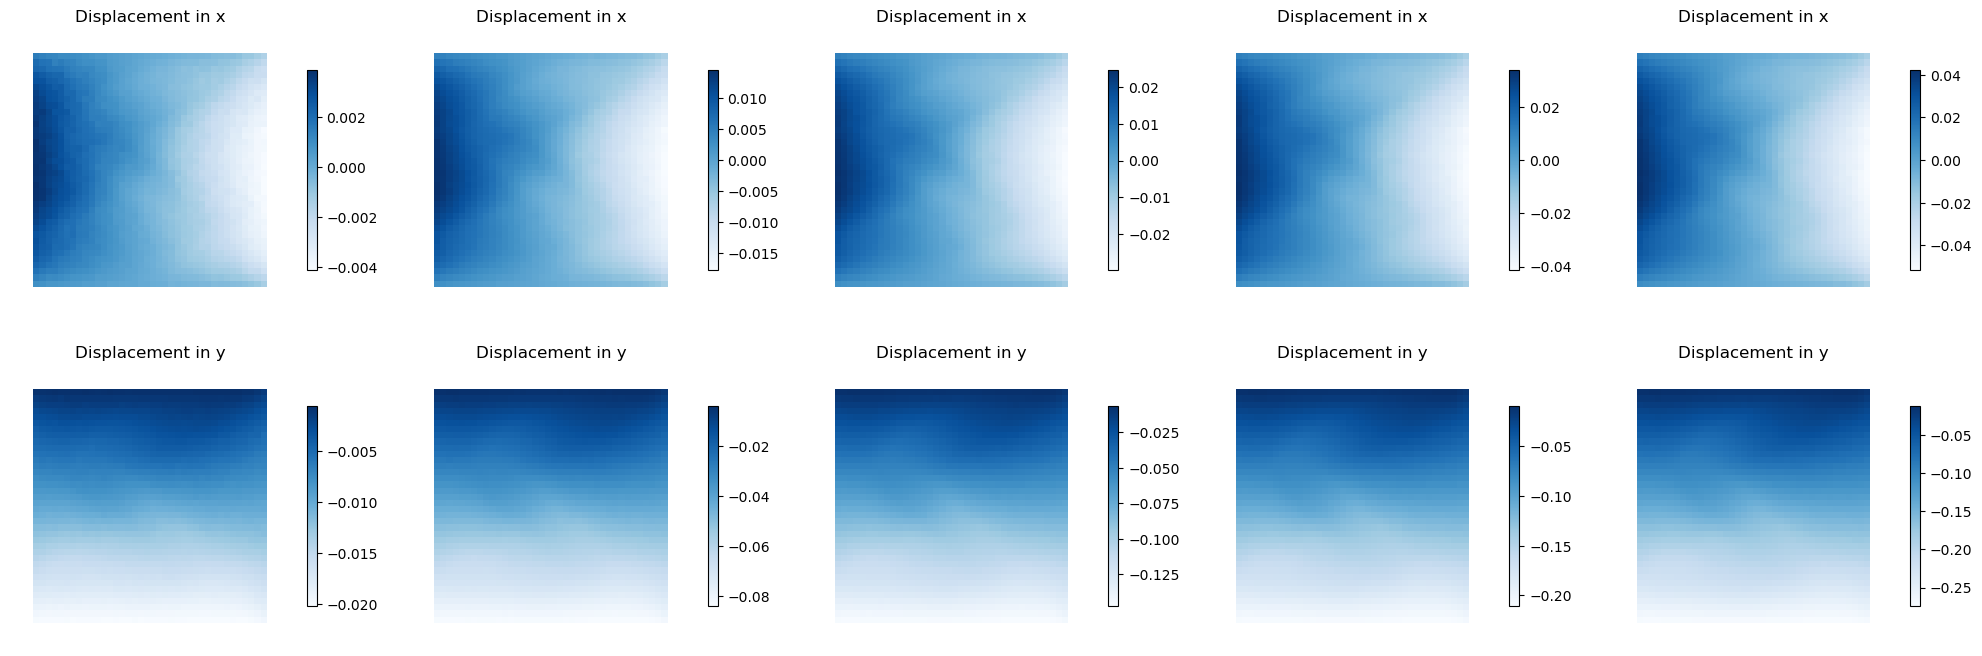

In [67]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = x.shape[0], x.shape[1]
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

disps_norm = []
n_panels = 5
fig, axes = plt.subplots(2,n_panels,figsize=(5*n_panels,8))
t_hist = np.arange(len(ux_hist))
disps_x_mean = []
disps_x_stdv = []
disps_y_mean = []
disps_y_stdv = []
for i in range(len(ux_hist)):
    t = t_hist[i]
    plotmesh(mesh.cells, mesh.points, ux_hist[i].flatten(), title='Displacement in x', ax=axes[0,i], ec='None'); 
    plotmesh(mesh.cells, mesh.points, uy_hist[i].flatten(), title='Displacement in y', ax=axes[1,i], ec='None'); 

    temp1 = ux_hist[i].flatten()
    temp2 = uy_hist[i].flatten()
    disps_x_mean.append(temp1.mean())
    disps_x_stdv.append(temp1.std())
    disps_y_mean.append(temp2.mean())
    disps_y_stdv.append(temp2.std())

    temp1 = (temp1 - temp1.mean())/temp1.std()
    temp2 = (temp2 - temp2.mean())/temp2.std()

    disps_norm.append(np.array([t*np.ones(len(temp1)), temp1, temp2]))
disps_norm = np.hstack(disps_norm)
disps_x_mean = jnp.hstack(disps_x_mean)
disps_x_stdv = jnp.hstack(disps_x_stdv)
disps_y_mean = jnp.hstack(disps_y_mean)
disps_y_stdv = jnp.hstack(disps_y_stdv)

In [68]:
a,b,ux_grid,uy_grid=u_hist_for_derivative[3]

print(ux_grid.T[19,:])
print(ux_grid.T[:,10])

[ 0.03307  0.03153  0.0297   0.02773  0.0254   0.0233   0.02196  0.01982  0.01732  0.01493  0.01278  0.01104  0.0099   0.00864  0.00698  0.0055   0.00434  0.00298  0.00099 -0.00083 -0.0034  -0.00599 -0.00893 -0.01107 -0.01376 -0.01591 -0.01801 -0.0203  -0.02218 -0.02392 -0.02619 -0.02833 -0.03039 -0.03247 -0.03494 -0.03588 -0.03829 -0.04118]
[0.00163 0.00341 0.00514 0.00663 0.0077  0.00891 0.00933 0.00944 0.00953 0.00937 0.00877 0.00831 0.0087  0.01009 0.01154 0.01228 0.01296 0.01296 0.01287 0.01278 0.01342 0.01436 0.01531 0.01594 0.01572 0.01517 0.01355 0.01269 0.0115  0.0097  0.00915 0.00929 0.00892 0.00853 0.00772 0.00667 0.00561 0.00405]


In [69]:
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/Experimental_Vahid.npy', 'rb') as f:
    coord_2_strain_params_V,t_hist_V, F_xx_mean_V, F_yy_mean_V, F_xy_mean_V, F_yx_mean_V=pickle.load(f)
with open('/home/amir/inverse_prob/params_for_noise_tuning/manu/Experimental_Amir.npy', 'rb') as f:
    coord_2_strain_params_A,t_hist_A, F_xx_mean_A, F_yy_mean_A, F_xy_mean_A, F_yx_mean_A=pickle.load(f)

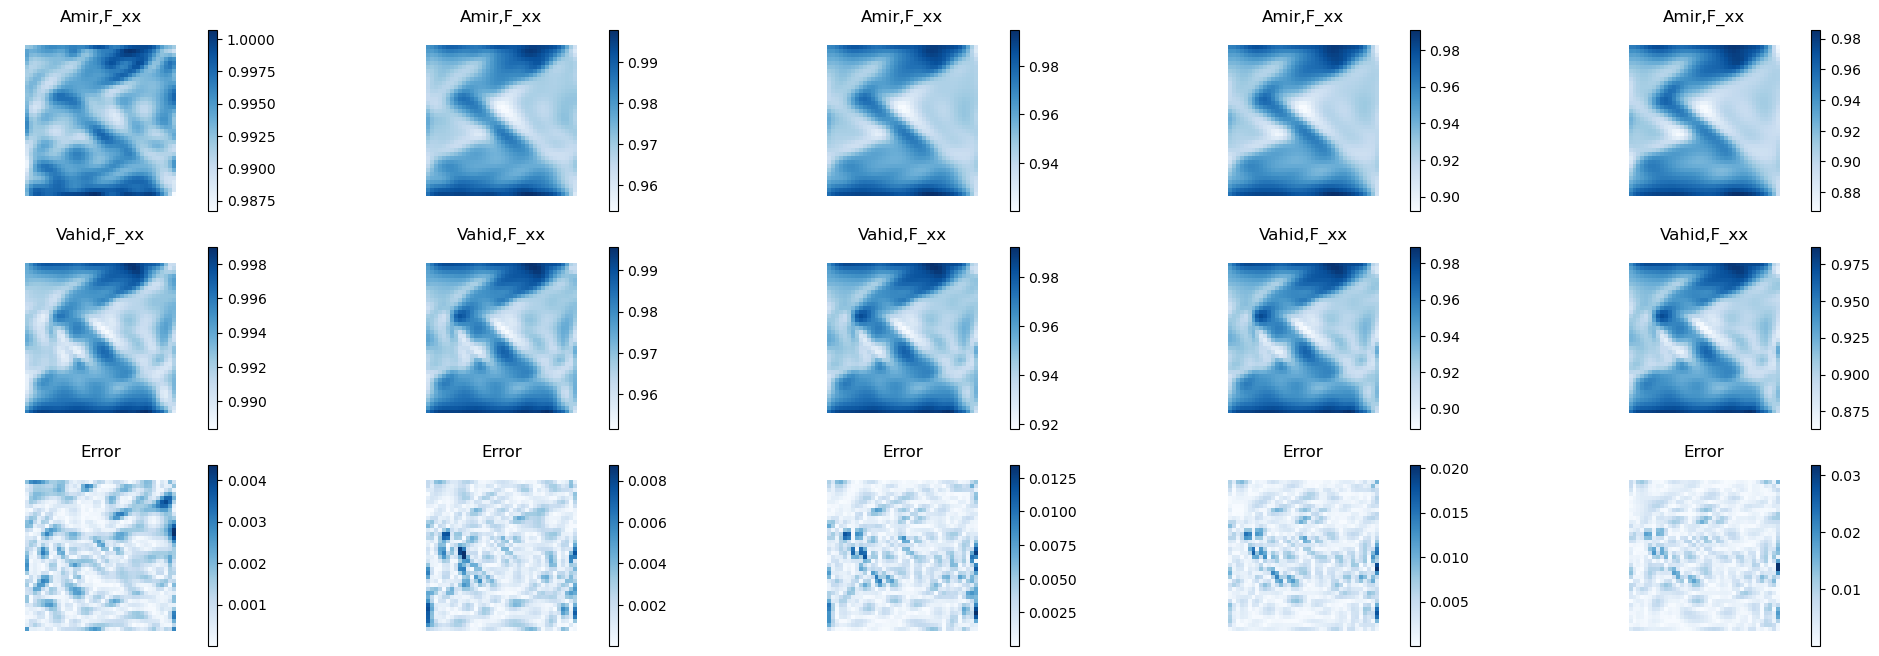

In [70]:
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist_A:
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_xx
    plotmesh(mesh.cells, mesh.points, F_xx, title='Amir,F_xx', ax=axes[0][t],ec='None')
    inp = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(inp, coord_2_strain_params_V).T
    F_for_error_V=F_xx
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_for_error_V[:,None],axis=1))
    plotmesh(mesh.cells, mesh.points, F_xx, title='Vahid,F_xx', ax=axes[1][t], ec='None'); 
    plotmesh(mesh.cells, mesh.points, F_for_error, title='Error', ax=axes[2][t], ec='None'); 

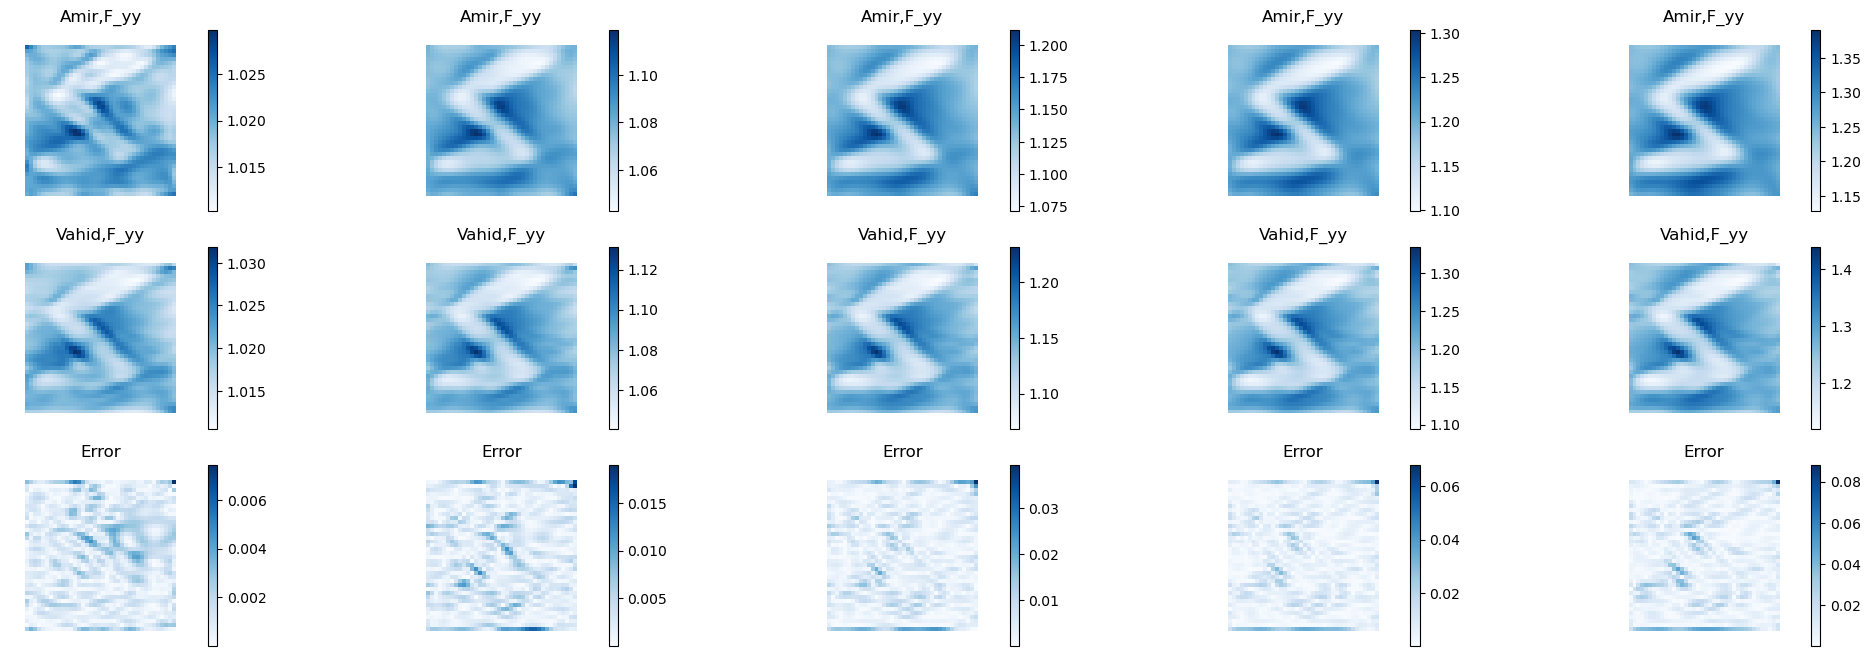

In [71]:
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist_A:
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_yy
    plotmesh(mesh.cells, mesh.points, F_yy, title='Amir,F_yy', ax=axes[0][t],ec='None')
    inp = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(inp, coord_2_strain_params_V).T
    F_for_error_V=F_yy
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_for_error_V[:,None],axis=1))
    plotmesh(mesh.cells, mesh.points, F_yy, title='Vahid,F_yy', ax=axes[1][t], ec='None'); 
    plotmesh(mesh.cells, mesh.points, F_for_error, title='Error', ax=axes[2][t], ec='None'); 

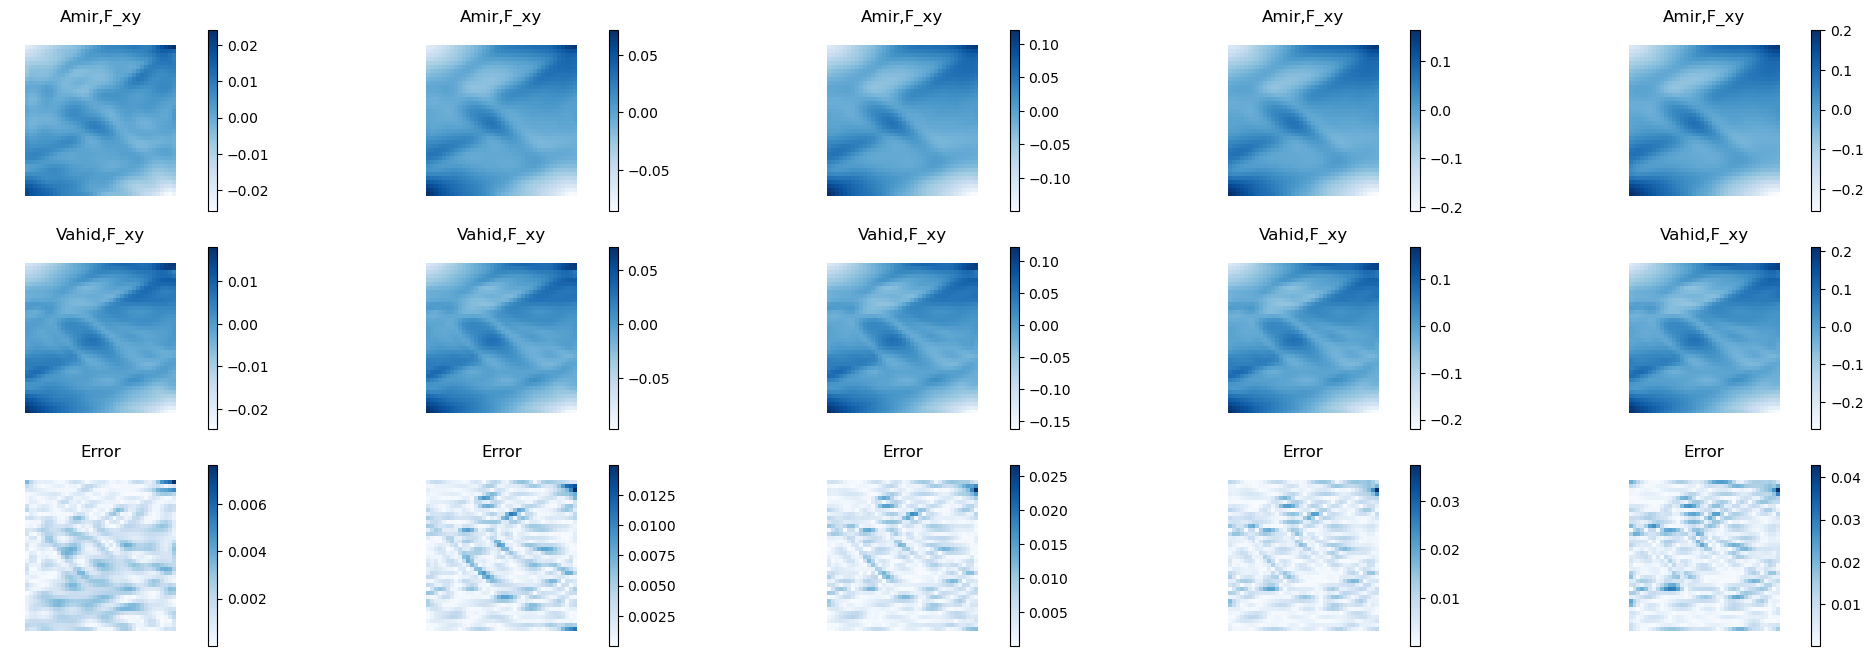

In [72]:
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist_A:
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_xy
    plotmesh(mesh.cells, mesh.points, F_xy, title='Amir,F_xy', ax=axes[0][t],ec='None')
    inp = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(inp, coord_2_strain_params_V).T
    F_for_error_V=F_xy
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_for_error_V[:,None],axis=1))
    plotmesh(mesh.cells, mesh.points, F_xy, title='Vahid,F_xy', ax=axes[1][t], ec='None'); 
    plotmesh(mesh.cells, mesh.points, F_for_error, title='Error', ax=axes[2][t], ec='None'); 

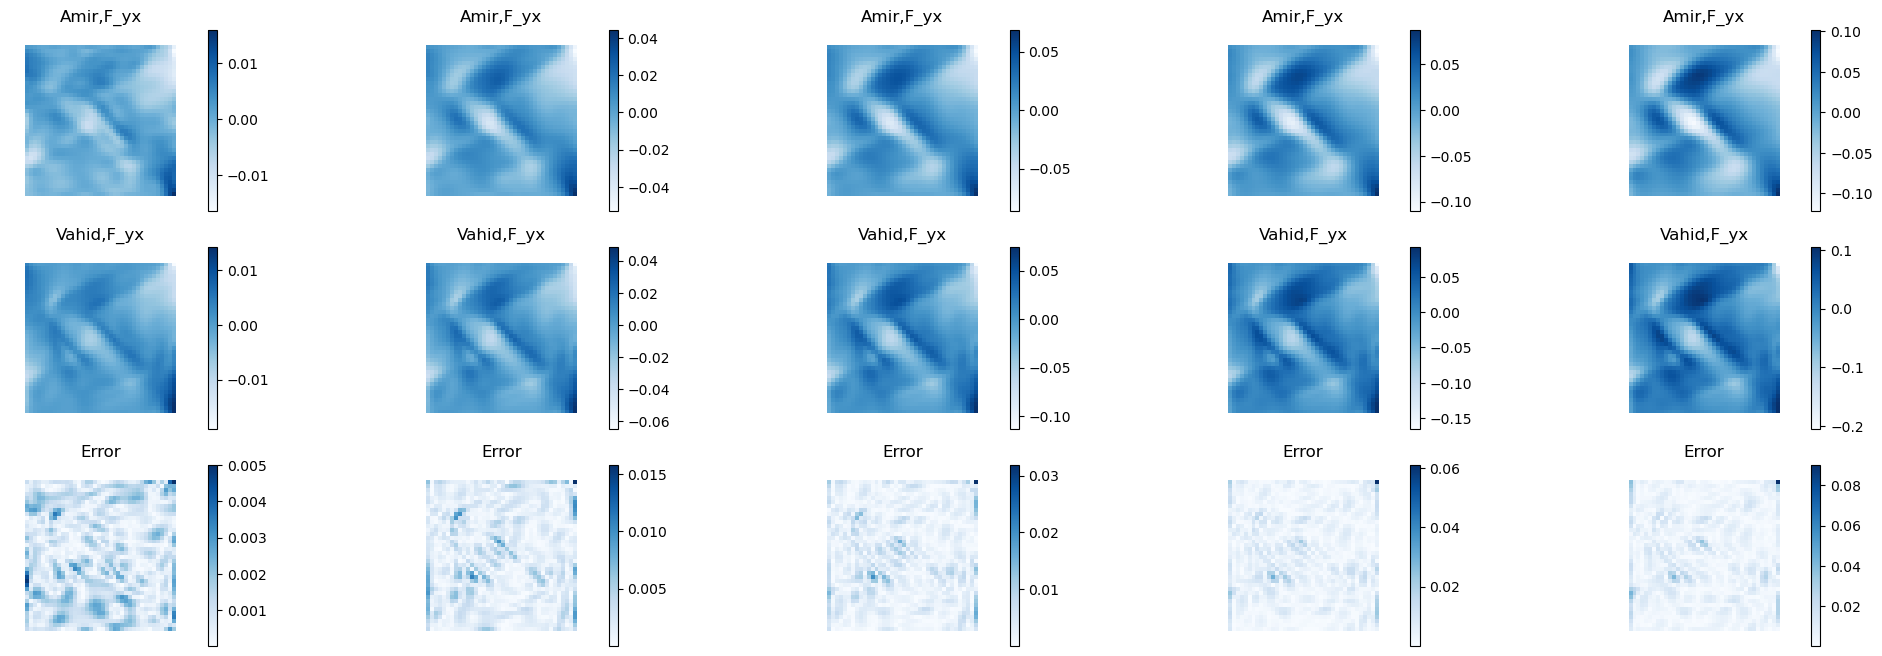

In [73]:
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist_A:
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_yx
    plotmesh(mesh.cells, mesh.points, F_yx, title='Amir,F_yx', ax=axes[0][t],ec='None')
    inp = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(inp, coord_2_strain_params_V).T
    F_for_error_V=F_yx
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_for_error_V[:,None],axis=1))
    plotmesh(mesh.cells, mesh.points, F_yx, title='Vahid,F_yx', ax=axes[1][t], ec='None'); 
    plotmesh(mesh.cells, mesh.points, F_for_error, title='Error', ax=axes[2][t], ec='None'); 

In [74]:
ux_hist=np.array(ux_hist)
uy_hist=np.array(uy_hist)
X_grid=elem_X[:,0].reshape((Nx,Ny)).T
Y_grid=elem_X[:,1].reshape((Nx,Ny)).T[::-1,:]
u_hist_for_derivative=[]
for ii in range(ux_hist.shape[0]):
        ux_hist
        u_hist_for_derivative.append([X_grid,Y_grid,ux_hist[ii,:,:],uy_hist[ii,:,:]])

In [75]:
def richardson_derivative(Z, h):
    """Calculates the derivatives using finite difference and Richardson extrapolation for step size h."""
    Z_x = np.zeros_like(Z)
    Z_y = np.zeros_like(Z)
    rows, cols = Z.shape
    for i in range(rows):
        for j in range(cols):
            if i == 0:  
                Z_y[i, j] = (Z[i + 1, j] - Z[i, j]) / h
            elif i == rows - 1:  
                Z_y[i, j] = (Z[i, j] - Z[i - 1, j]) / h
            else:  
                dy_h = (Z[i + 1, j] - Z[i - 1, j]) / (2 * h)
                
        
                f_y_plus_h_half = (Z[i + 1, j] + Z[i, j]) / 2
                f_y_minus_h_half = (Z[i - 1, j] + Z[i, j]) / 2
                
                dy_h_over_2 = (f_y_plus_h_half - f_y_minus_h_half) / h

               
                #Z_y[i, j] = (4 * dy_h_over_2 - dy_h) / 3
                Z_y[i, j] = dy_h
            if j == 0: 
                Z_x[i, j] = (Z[i, j + 1] - Z[i, j]) / h
            elif j == cols - 1: 
                Z_x[i, j] = (Z[i, j] - Z[i, j - 1]) / h
            else:  
                dx_h = (Z[i, j + 1] - Z[i, j - 1]) / (2 * h)
                
                f_x_plus_h_half = (Z[i, j + 1] + Z[i, j]) / 2
                f_x_minus_h_half = (Z[i, j - 1] + Z[i, j]) / 2
                
                dx_h_over_2 = (f_x_plus_h_half - f_x_minus_h_half) / h

                #Z_x[i, j] = (4 * dx_h_over_2 - dx_h) / 3
                Z_x[i, j] = dx_h

    return Z_x,Z_y
F_with_FDM=np.zeros((5,38*38,2,2))
for ii in range(len(u_hist_for_derivative)):
           a,b,ux_grid,uy_grid=u_hist_for_derivative[ii]
           #print(ux_grid)
           uxx,uxy=richardson_derivative(ux_grid.T,1/(Nx-1))
           #print('derivative')
           #print(uxx)
           uyx,uyy=richardson_derivative(uy_grid.T,1/(Nx-1))
           id_mesh=0
           for i in range(uxx.shape[0]):
                for j in range(uxx.shape[1]):
                     F_with_FDM[ii,id_mesh, :,:]=np.array([[uxx[j,i]+1,uxy[j,i]],[uyx[j,i],uyy[j,i]+1]])
                     id_mesh+=1
#print(uy_grid.T[::-1,:])
# plt.scatter(elem_X[:,0], elem_X[:,1])
# a=elem_X[:,0].reshape((Nx,Ny)).T
# b=elem_X[:,1].reshape((Nx,Ny)).T[::-1,:]
# print(a)
# print(b)


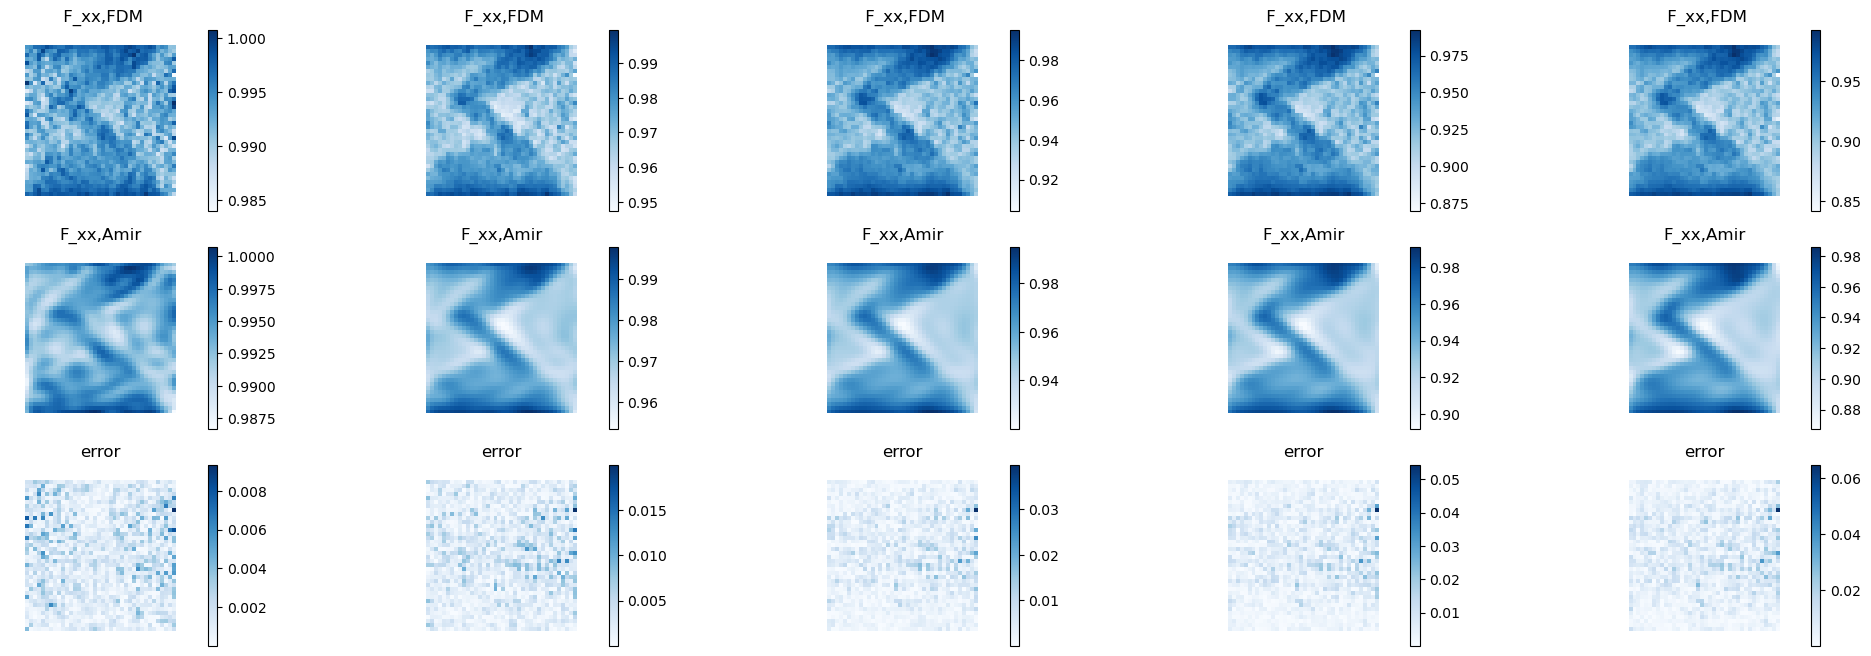

In [76]:
#F_mean = []
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist:
    F=F_with_FDM[t,:,0,0]
    F_error_FDM=F
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F, title=' F_xx,FDM', ax=axes[0][t], ec='None'); 
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_xx
    
#     # ground truth
#     E = E_hist_dic[t]
#     evals, efuns = jnp.linalg.eigh(E)
#     E_11, E_22 = evals.T
#     mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_xx, title='F_xx,Amir', ax=axes[1][t], ec='None'); 
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_error_FDM[:,None],axis=1))
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_for_error, title='error', ax=axes[2][t], ec='None'); 
# # F_mean = np.array(F_mean).mean(axis=1)
# F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = F_mean[:,0,0], F_mean[:,1,1], F_mean[:,0,1], F_mean[:,1,0]


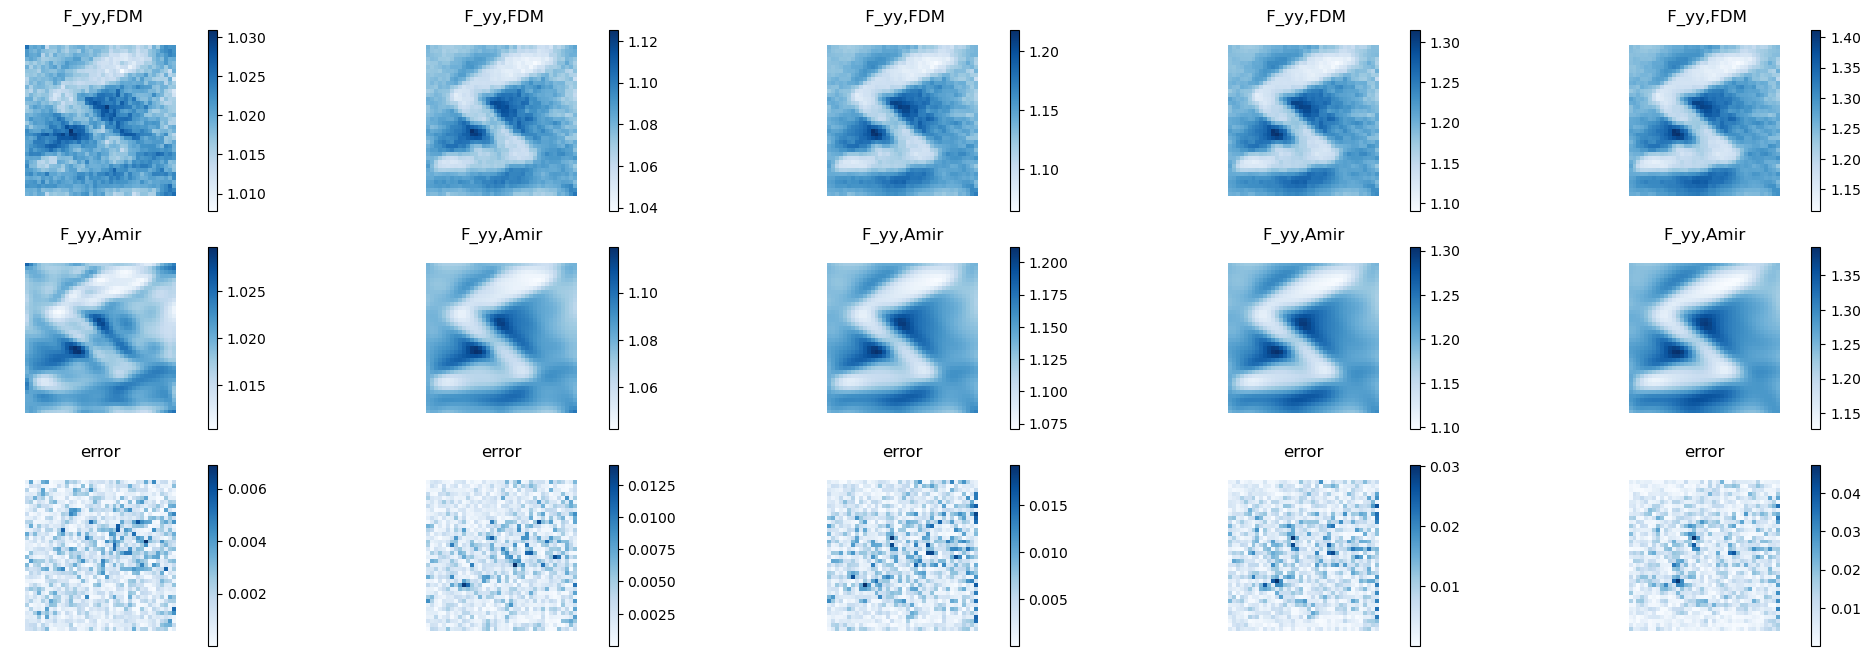

In [77]:
#F_mean = []
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist:
    F=F_with_FDM[t,:,1,1]
    F_error_FDM=F
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F, title=' F_yy,FDM', ax=axes[0][t], ec='None'); 
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_yy
    
#     # ground truth
#     E = E_hist_dic[t]
#     evals, efuns = jnp.linalg.eigh(E)
#     E_11, E_22 = evals.T
#     mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_yy, title='F_yy,Amir', ax=axes[1][t], ec='None'); 
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_error_FDM[:,None],axis=1))
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_for_error, title='error', ax=axes[2][t], ec='None'); 
# # F_mean = np.array(F_mean).mean(axis=1)
# F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = F_mean[:,0,0], F_mean[:,1,1], F_mean[:,0,1], F_mean[:,1,0]


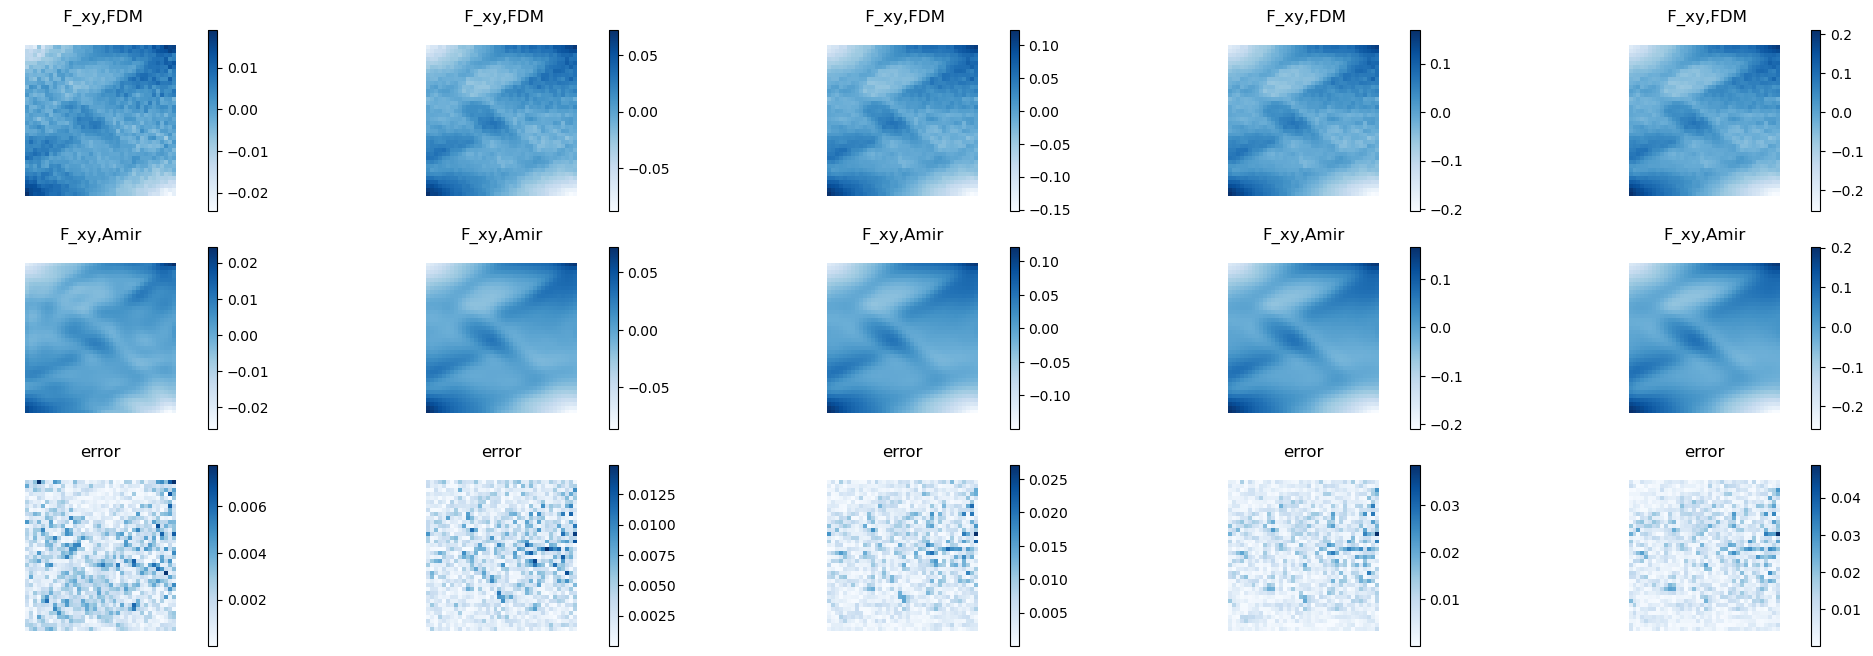

In [78]:
#F_mean = []
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist:
    F=F_with_FDM[t,:,0,1]
    F_error_FDM=F
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F, title=' F_xy,FDM', ax=axes[0][t], ec='None'); 
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_xy
    
#     # ground truth
#     E = E_hist_dic[t]
#     evals, efuns = jnp.linalg.eigh(E)
#     E_11, E_22 = evals.T
#     mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_xy, title='F_xy,Amir', ax=axes[1][t], ec='None'); 
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_error_FDM[:,None],axis=1))
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_for_error, title='error', ax=axes[2][t], ec='None'); 
# # F_mean = np.array(F_mean).mean(axis=1)
# F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = F_mean[:,0,0], F_mean[:,1,1], F_mean[:,0,1], F_mean[:,1,0]


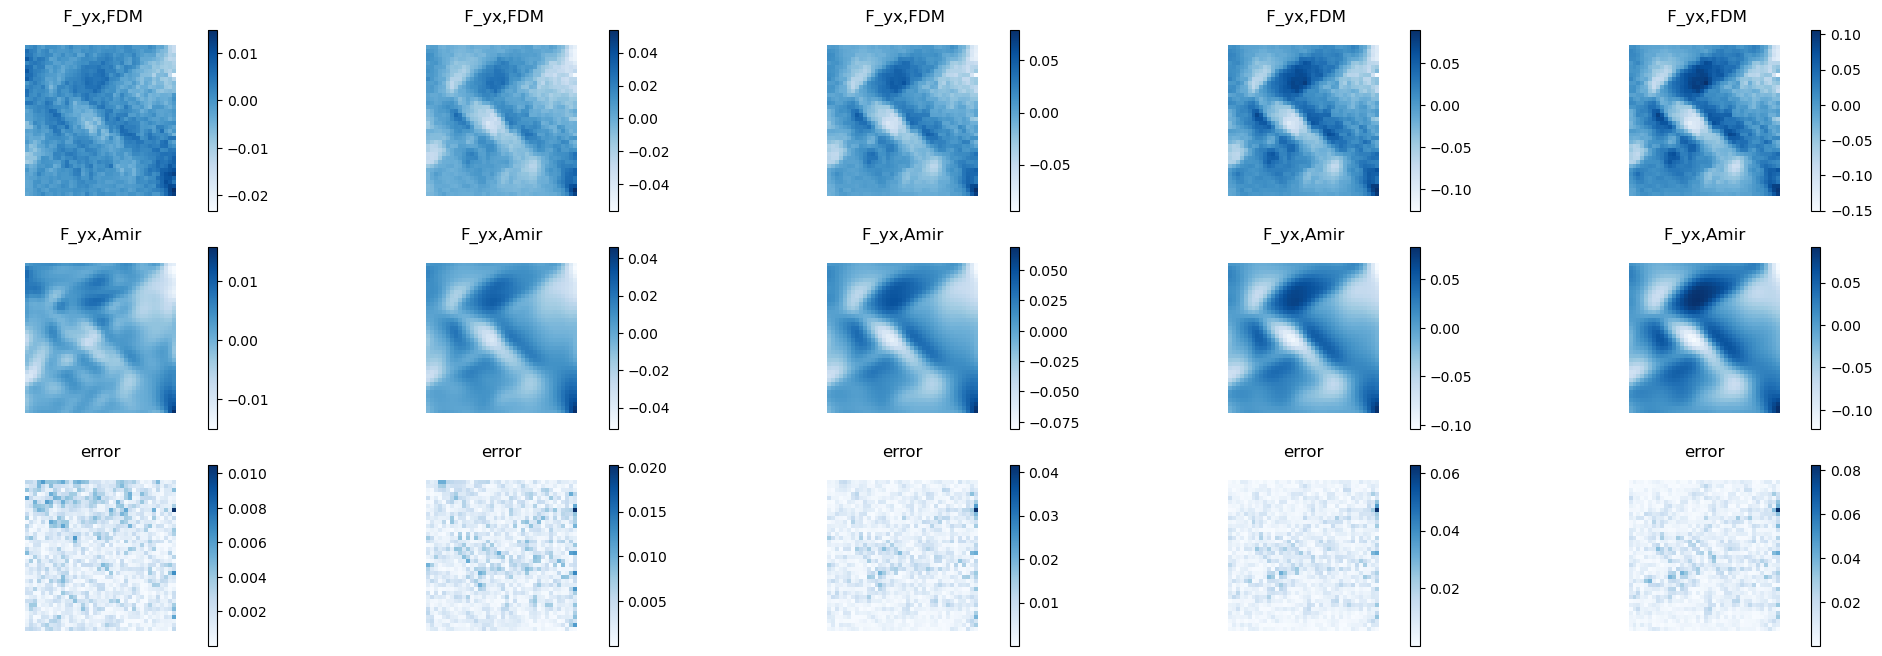

In [43]:
#F_mean = []
fig, axes = plt.subplots(3,5,figsize=(25,8))
for t in t_hist:
    F=F_with_FDM[t,:,1,0]
    F_error_FDM=F
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F, title=' F_yx,FDM', ax=axes[0][t], ec='None'); 
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params_A).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    F_for_error_A=F_yx
    
#     # ground truth
#     E = E_hist_dic[t]
#     evals, efuns = jnp.linalg.eigh(E)
#     E_11, E_22 = evals.T
#     mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_yx, title='F_yx,Amir', ax=axes[1][t], ec='None'); 
    F_for_error=np.squeeze(np.linalg.norm(F_for_error_A[:,None]-F_error_FDM[:,None],axis=1))
    if t < 5:
        plotmesh(mesh.cells, mesh.points, F_for_error, title='error', ax=axes[2][t], ec='None'); 
# # F_mean = np.array(F_mean).mean(axis=1)
# F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean = F_mean[:,0,0], F_mean[:,1,1], F_mean[:,0,1], F_mean[:,1,0]
